In [1]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

# Dask will automatically submit SLURM jobs for you
cluster = SLURMCluster(
    cores=8,
    memory="128GB",
    processes=8,
    walltime="08:00:00",
    #qos="np",
    #account='spitfabi',
    #interface='ib0'  # or 'eth0', depends on your HPC
    job_extra_directives=[
        "--account=spitvent",
        "--qos=np"
        # "--constraint=haswell",
        # "--exclusive",
        # "--mail-type=END,FAIL",
        # "--mail-user=your.email@domain.com"
    ]
)

# Scale to desired number of workers
cluster.scale(jobs=1)  # This submits 1 SLURM job
# Connect client
client = Client(cluster)
#cluster.adapt(minimum_jobs=1, maximum_jobs=4)


In [2]:
import check_run as cr
from matplotlib import pyplot as plt
import xarray as xr
import os
from scipy import stats
import numpy as np
import cartopy.crs as ccrs

In [3]:
import importlib as imp
imp.reload(cr)

<module 'check_run' from '/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py'>

In [4]:
read_again = []

cart_exp = '/ec/res4/scratch/{}/ece4/'
cart_out = '/ec/res4/hpcperm/itcv/analysis/'


In [5]:
exps = [ ['pct6', 'pic6'], ['pct7', 'pic7'],['pct1', 'pic1'], ['pct3', 'pic3'], ['pct2', 'pic2'], ['pct4', 'pic4'], ['1pc0', 'ctl0']]
colors=['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon']

# Big zonal bands

In [6]:
lambdas = np.array([[1.15206076, 1.15950603, 1.26772497, 1.4947282 , 1.30711237, 1.2470465 , 1.12615353],
       [0.06806254, 0.08391953, 0.07920348, 0.05674204, 0.05236332, 0.06170118, 0.05077112],
       [0.25578123, 0.22853754, 0.23950158, 0.25380897, 0.24667626, 0.25473303, 0.22853433],
       [0.7362082 , 0.73184585, 0.82795796, 0.95816573, 0.85661021, 0.81749996, 0.74858152],
       [0.05947394, 0.07899901, 0.08876487, 0.19542786, 0.11277818, 0.0904261 , 0.06102327],
       [0.03253485, 0.0362041 , 0.03229708, 0.0305836 , 0.03868441, 0.02268623, 0.03724328],
       [0.31525517, 0.30753655, 0.32826645, 0.44923683, 0.35945444, 0.34515913, 0.2895576 ]])
kappas = np.array([[ 0.84123329,  0.99007471,  1.0855393 ,  1.3471938 ,  1.19594174, 0.92113063,  0.90884158],
       [ 0.2079748 ,  0.16950222,  0.16747797,  0.13956098,  0.16785692, 0.14245734,  0.15527706],
       [ 0.26415298,  0.30002378,  0.2970116 ,  0.55365875,  0.48201408, 0.34946671,  0.36489361],
       [ 0.23564626,  0.11832069,  0.10946587, -0.03732737,  0.06626532, 0.07127016,  0.16060662],
       [ 0.26832789,  0.51523652,  0.5709451 ,  0.59219369,  0.50292184, 0.46652975,  0.38755565],
       [-0.13486864, -0.1130085 , -0.05936124,  0.09910775, -0.0231164 ,-0.10859332, -0.15949136],
       [ 0.53248087,  0.81526031,  0.8679567 ,  1.14585244,  0.98493591, 0.81599646,  0.75244926]])

In [7]:
lambdas_agg = np.array([[1.15206076, 1.15950603, 1.26772497, 1.4947282 , 1.30711237, 1.2470465 , 1.12615353],#global
       [0.06806254+0.03253485, 0.08391953+0.0362041, 0.07920348+0.03229708, 0.05674204+0.0305836, 0.05236332+0.03868441, 0.06170118+0.02268623, 0.05077112+0.03724328], #high
       [0.31525517, 0.30753655, 0.32826645, 0.44923683, 0.35945444, 0.34515913, 0.2895576 ], #mid 
       [0.7362082 , 0.73184585, 0.82795796, 0.95816573, 0.85661021, 0.81749996, 0.74858152], #low
       ])
kappas_agg = np.array([[ 0.84123329,  0.99007471,  1.0855393 ,  1.3471938 ,  1.19594174, 0.92113063,  0.90884158], #global
       [ 0.2079748-0.13486864 ,  0.16950222-0.1130085,  0.16747797-0.05936124,  0.13956098+0.09910775,  0.16785692-0.0231164, 0.14245734-0.10859332,  0.15527706-0.15949136], #high
       [ 0.53248087,  0.81526031,  0.8679567 ,  1.14585244,  0.98493591, 0.81599646,  0.75244926], #mid
       [ 0.23564626,  0.11832069,  0.10946587, -0.03732737,  0.06626532, 0.07127016,  0.16060662], #low
       ])

Further step: decompose lambda into components (clear sky - clouds) \
This code looks only at the diagonal, but we have seen that is probably not important and should expand to cross-region correlations

In [8]:
lambdas_c_agg = np.array(([[[ 1.15206078,  1.15950606,  1.26772496,  1.49472821,
          1.30711233,  1.2470465 ,  1.12615355],
        [ 0.10059738,  0.12012361,  0.11150056,  0.08732562,
          0.09104772,  0.08438742,  0.08801439],
        [ 0.31525518,  0.30753656,  0.32826645,  0.4492368 ,
          0.35945443,  0.34515912,  0.28955761],
        [ 0.73620822,  0.73184589,  0.82795794,  0.95816579,
          0.85661018,  0.81749996,  0.74858155]],

       [[ 0.94414541,  0.933161  ,  0.99757514,  1.11487994,
          0.9827361 ,  0.96180016,  0.91422951],
        [-0.04263801, -0.03289284, -0.01332782, -0.02966719,
         -0.05993224, -0.062426  , -0.05872827],
        [ 0.42199805,  0.38717244,  0.40655967,  0.47676232,
          0.43014903,  0.42732605,  0.39796588],
        [ 0.56478536,  0.5788814 ,  0.60434329,  0.66778481,
          0.61251931,  0.59690011,  0.5749919 ]],

       [[ 1.67035039,  1.65191817,  1.65714361,  1.66059384,
          1.67030896,  1.6757998 ,  1.69214005],
        [ 0.35981252,  0.36555836,  0.33327797,  0.30898443,
          0.34678807,  0.34372572,  0.39659746],
        [ 0.68017508,  0.64115975,  0.65481175,  0.61345195,
          0.64404643,  0.66843093,  0.65575443],
        [ 0.63036279,  0.64520006,  0.66905389,  0.73815746,
          0.67947446,  0.66364315,  0.63978816]],

       [[-0.72620521, -0.71875693, -0.65956853, -0.54571398,
         -0.68757308, -0.71399969, -0.77791035],
        [-0.40245054, -0.3984512 , -0.34660578, -0.33865161,
         -0.40672032, -0.40615172, -0.45532572],
        [-0.25817705, -0.25398722, -0.24825209, -0.13668962,
         -0.21389743, -0.24110494, -0.25778851],
        [-0.06557763, -0.06631852, -0.06471065, -0.07037275,
         -0.06695532, -0.06674303, -0.06479612]],

       [[ 0.20791537,  0.22634505,  0.27014982,  0.37984828,
          0.32437622,  0.28524634,  0.21192406],
        [ 0.14323539,  0.15301645,  0.12482838,  0.11699282,
          0.15097995,  0.14681342,  0.14674267],
        [-0.10674287, -0.07963588, -0.07829322, -0.02752551,
         -0.0706946 , -0.08216693, -0.10840828],
        [ 0.17142286,  0.15296447,  0.22361466,  0.29038098,
          0.24409087,  0.22059986,  0.17358966]],

       [[-0.09653769, -0.11501256, -0.08170177, -0.08831663,
         -0.0941405 , -0.10560385, -0.1169511 ],
        [-0.12473484, -0.13224357, -0.12039154, -0.11033615,
         -0.12699908, -0.12965821, -0.1441921 ],
        [-0.0369829 , -0.04330067, -0.03228809, -0.03296331,
         -0.02715357, -0.03652005, -0.04765914],
        [ 0.06518005,  0.06053168,  0.07097786,  0.05498283,
          0.06001216,  0.0605744 ,  0.07490013]],

       [[ 0.30445309,  0.34135758,  0.35185162,  0.46816488,
          0.41851676,  0.39085017,  0.32887516],
        [ 0.26797023,  0.28526003,  0.24521993,  0.22732896,
          0.27797904,  0.27647162,  0.29093477],
        [-0.06975997, -0.03633523, -0.04600512,  0.00543777,
         -0.04354101, -0.04564689, -0.06074914],
        [ 0.10624283,  0.09243278,  0.15263681,  0.23539814,
          0.18407873,  0.16002544,  0.09868953]]]))

# 1. K and L at midlatitudes through clouds

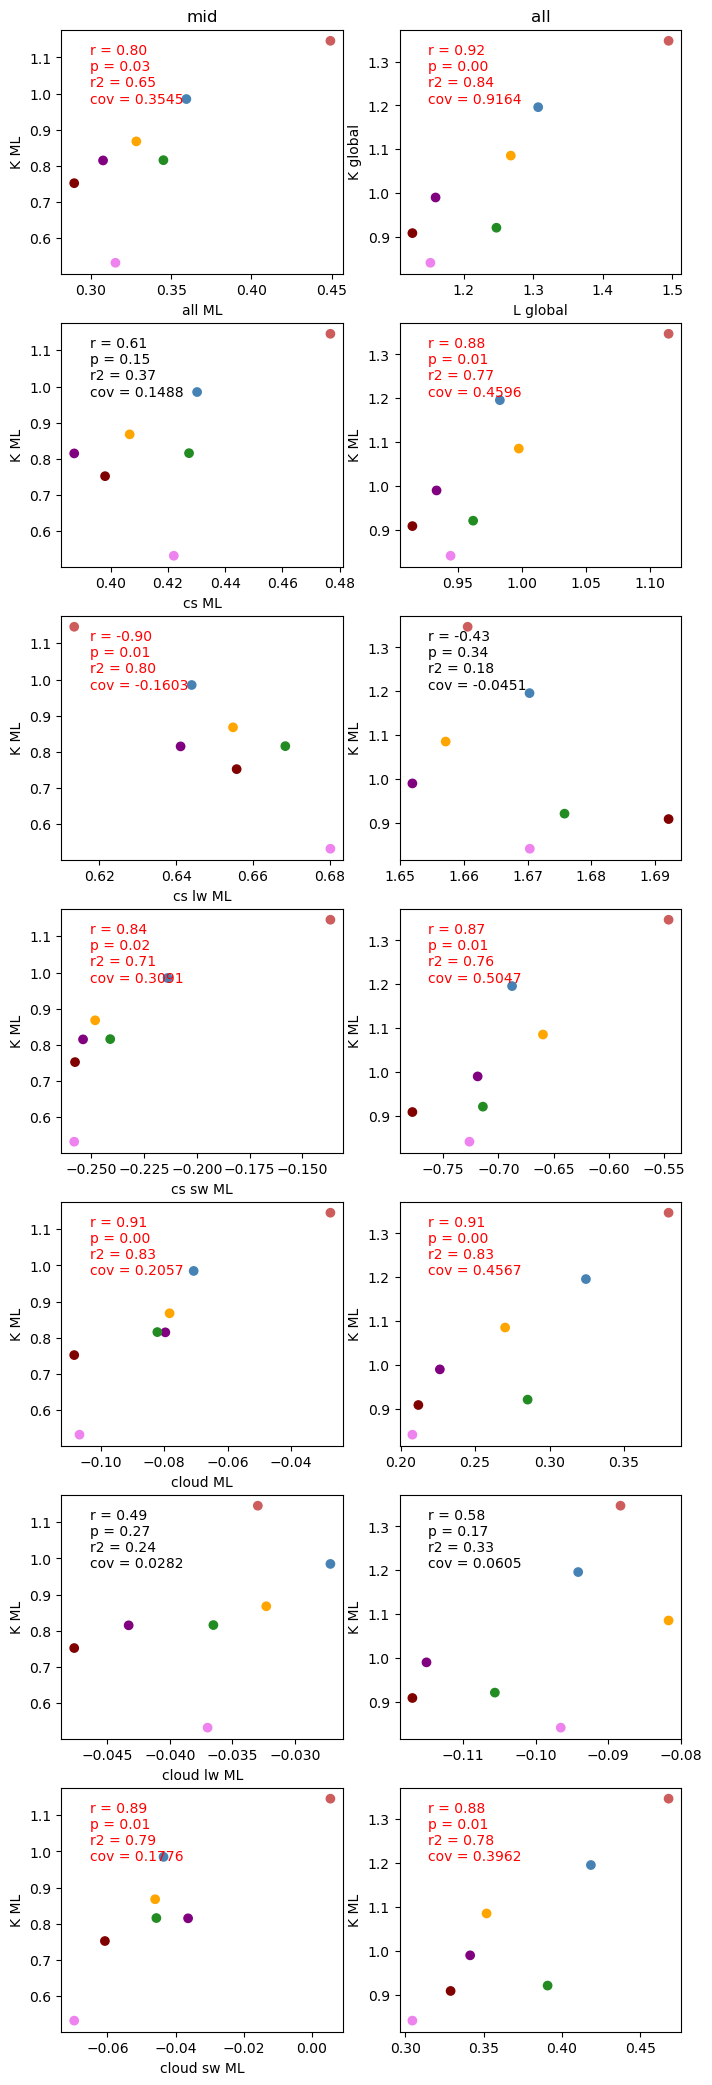

In [ ]:
fig, ax = plt.subplots(7,2, figsize=(8,26))
labels = ['all', 'high', 'mid','low']
forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

indexes = [2,0]
exps_indexes = [0,1,2,3,4,5,6]
# lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
denom_global = sigma_Kg * sigma_Lg

for i in range(7):
    for j, index in enumerate(indexes):
        a, b, r_value, p_value, std_err =  stats.linregress(lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes])
        ax[i,j].scatter(lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes], color=colors[exps_indexes])
        cov = np.cov(lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes])[0,1]/denom_global
        #ax[i,j].plot(lambdas_c[i,index], [a*(x) + b for x in lambdas_c[i,index]], color='black', linestyle='--', label=f'Fit {labels[index]}')
        if r_value**2 > 0.4:
            color_text = 'red'
        else:         
            color_text = 'black'
        ax[i,j].text(0.1, 0.7, f'r = {r_value:.2f}\np = {p_value:.2f}\nr2 = {r_value**2:.2f}\ncov = {cov:.4f}', transform=ax[i,j].transAxes, color=color_text)

        if i == 0:
            ax[i,j].set_title(labels[index])
    
        ax[i,0].set_xlabel(forcings[i]+ ' ML')
        ax[i,j].set_ylabel('K ML')
    
ax[0,1].set_ylabel('K global')
ax[0,1].set_xlabel('L global')
plt.show()

In [15]:
imp.reload(cr)

cre = []
for i, exp in enumerate(exps):
    rlntcs_n = cr.return_var(exp, 'itcv', 'rlntcs', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    rlntcs_s = cr.return_var(exp, 'itcv', 'rlntcs', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    rsntcs_n = cr.return_var(exp, 'itcv', 'rsntcs', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    rsntcs_s = cr.return_var(exp, 'itcv', 'rsntcs', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    rlnt_n = cr.return_var(exp, 'itcv', 'rlnt', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    rlnt_s = cr.return_var(exp, 'itcv', 'rlnt', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    rsnt_n = cr.return_var(exp, 'itcv', 'rsnt', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    rsnt_s = cr.return_var(exp, 'itcv', 'rsnt', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    cre_n = rlnt_n + rsnt_n - rlntcs_n - rsntcs_n
    cre_s = rlnt_s + rsnt_s - rlntcs_s - rsntcs_s
    cre.append((cre_n + cre_s))

cre = np.array(cre)

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


...

/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


In [ ]:
imp.reload(cr)

clouds_mid = []
clouds_low = []
clouds_high = []

for i, exp in enumerate(exps):
    clouds_exp_s = cr.return_var(exp, 'itcv', 'cll', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    clouds_exp_n = cr.return_var(exp, 'itcv', 'cll', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    clouds_exp_sm = cr.return_var(exp, 'itcv', 'clm', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    clouds_exp_nm = cr.return_var(exp, 'itcv', 'clm', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)

    clouds_exp_sl = cr.return_var(exp, 'itcv', 'clh', 'atm', lat_bounds=[-60,-30], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    clouds_exp_nl = cr.return_var(exp, 'itcv', 'clh', 'atm', lat_bounds=[30,60], lon_bounds= [180,-180],cart_exp = cart_exp, cart_out=cart_out)
    
    clouds_mid.append((clouds_exp_nm+clouds_exp_sm)/2)
    clouds_low.append((clouds_exp_n+clouds_exp_s)/2)
    clouds_high.append((clouds_exp_nl+clouds_exp_sl)/2)

clouds_mid = np.array(clouds_mid)
clouds_low = np.array(clouds_low)
clouds_high = np.array(clouds_high)

In [10]:
clouds = clouds_low + clouds_mid + clouds_high

Different options for showing common drivers

In [ ]:
# fig, ax = plt.subplots(1,1, figsize=(5,5))
# labels = ['all', 'high', 'mid','low']
# forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
# colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

# indexes = [2,0]
# exps_indexes = [0,1,2,3,4,5,6]
# # lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

# sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
# sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
# denom_global = sigma_Kg * sigma_Lg
# ax.scatter(clouds[exps_indexes], kappas_agg[2,exps_indexes], color=colors[exps_indexes])
# #ax.scatter(lambdas_c_agg[4,2][exps_indexes], kappas_agg[2,exps_indexes], color=colors[exps_indexes])
# ax.set_xlabel(forcings[4]+ ' ML')
# ax.set_ylabel('K ML')

# ax2 = ax.twinx()
# ax2.scatter(clouds[exps_indexes], lambdas_agg[2,exps_indexes], color=colors[exps_indexes], marker='x')
# #ax2.scatter(lambdas_c_agg[4,2][exps_indexes], lambdas_agg[2,exps_indexes], color=colors[exps_indexes], marker='x')
# ax2.set_ylabel(r'$\lambda$ ML')
# plt.show()

In [ ]:
# fig, ax = plt.subplots(1,1, figsize=(5,5))
# labels = ['all', 'high', 'mid','low']
# forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
# colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

# indexes = [2,0]
# exps_indexes = [0,1,2,3,4,5,6]
# # lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

# sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
# sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
# denom_global = sigma_Kg * sigma_Lg

# scatter = ax.scatter(lambdas_agg[2,exps_indexes], kappas_agg[2,exps_indexes], c=(clouds[exps_indexes]), cmap='viridis')
# plt.colorbar(scatter, label='cloud change ML')
# ax.set_xlabel(r'$\lambda$ ML')
# ax.set_ylabel('K ML')
# plt.show()

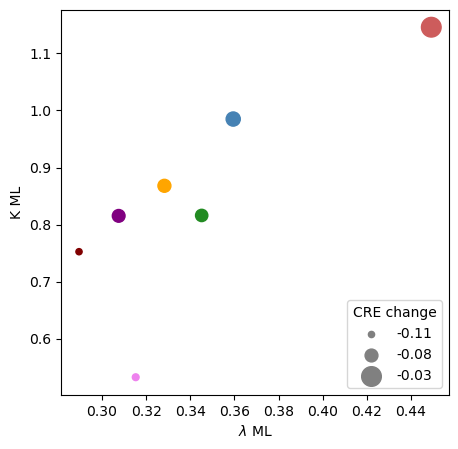

In [16]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
labels = ['all', 'high', 'mid','low']
forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

indexes = [2,0]
exps_indexes = [0,1,2,3,4,5,6]
# lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
denom_global = sigma_Kg * sigma_Lg

s_vals = (lambdas_c_agg[4,2,exps_indexes]) #abs(clouds[exps_indexes])
s_scaled = 20 + (s_vals - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

scatter = ax.scatter(lambdas_agg[2,exps_indexes], kappas_agg[2,exps_indexes], color=colors, s=s_scaled) #, sizes=(20,50))
ax.set_xlabel(r'$\lambda$ ML')
ax.set_ylabel('K ML')

ref_values = [s_vals.min(), s_vals.mean(), s_vals.max()]  # or pick specific values
ref_sizes  = 20 + (np.array(ref_values) - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

legend_handles = [
    ax.scatter([], [], s=size, color='gray', label=f'{val:.2f}')
    for val, size in zip(ref_values, ref_sizes)
]

ax.legend(handles=legend_handles, title='CRE change', loc='lower right')

plt.show()

# 2. K at ML and L at LL through ocean pathway

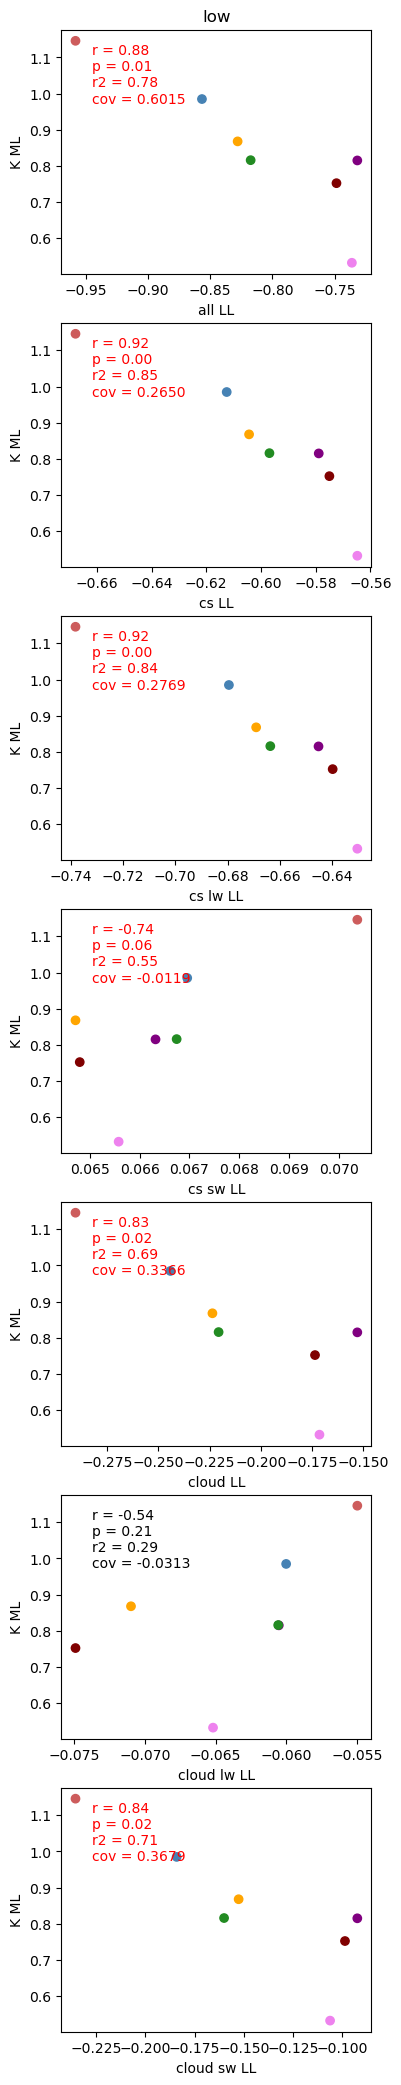

In [ ]:
fig, ax = plt.subplots(7,1, figsize=(4,26))
labels = ['all', 'high', 'mid','low']
forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

exps_indexes = [0,1,2,3,4,5,6]
# lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
denom_global = sigma_Kg * sigma_Lg

for i in range(7):
        a, b, r_value, p_value, std_err =  stats.linregress(lambdas_c_agg[i,3][exps_indexes], kappas_agg[2,exps_indexes])
        ax[i].scatter(-lambdas_c_agg[i,3][exps_indexes], kappas_agg[2,exps_indexes], color=colors[exps_indexes])
        cov = np.cov(lambdas_c_agg[i,3][exps_indexes], kappas_agg[2,exps_indexes])[0,1]/denom_global
        #ax[i].plot(lambdas_c[i,3], [a*(x) + b for x in lambdas_c[i,3]], color='black', linestyle='--', label=f'Fit {labels[3]}')
        if r_value**2 > 0.4:
            color_text = 'red'
        else:         
            color_text = 'black'
        ax[i].text(0.1, 0.7, f'r = {r_value:.2f}\np = {p_value:.2f}\nr2 = {r_value**2:.2f}\ncov = {cov:.4f}', transform=ax[i].transAxes, color=color_text)

        if i == 0:
            ax[i].set_title(labels[3])
    
        ax[i].set_xlabel(forcings[i]+ ' LL')
        ax[i].set_ylabel('K ML')
    
plt.show()

Tests with Hadley cell

In [17]:
imp.reload(cr)
fig, axs = plt.subplots(7,3, subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}, figsize=(15,20))
#fig2, bxs = plt.subplots(7,1, figsize = (8,22))

map_70 = np.zeros([7,90,180])
for i, exp in enumerate(exps):
    map_70, lats, lons = cr.plot_anom_map(exp, 'itcv', var='omega', map70=map_70,index=i, domain='atm3d', label = 'C', ref_exp=exp[1], cart_exp=cart_exp, cart_out=cart_out, ax=axs[i])

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


: 

: 

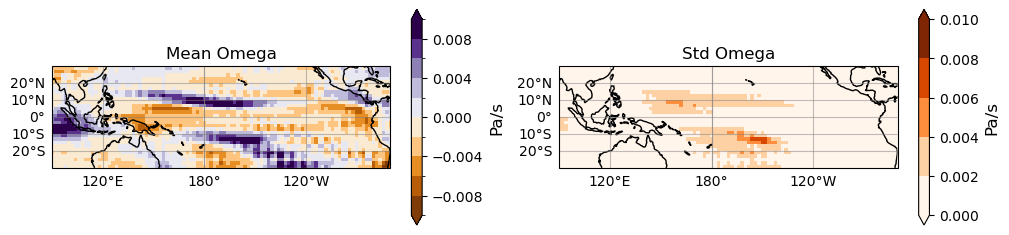

In [49]:
fig, axs = plt.subplots(1,2, subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}, figsize=(12,4))
from matplotlib import colors as mcolors
clevels_pi = np.arange(-0.01,0.012,0.002)  # for sst
divnorm = mcolors.BoundaryNorm(clevels_pi, plt.colormaps['RdBu_r'].N, clip=True)

c = axs[0].pcolormesh(lons, lats, map_70.mean(axis=0), cmap='PuOr', transform=ccrs.PlateCarree(), norm=divnorm)
gl = axs[0].gridlines(draw_labels={"bottom": "x", "left": "y"}, color='gray', alpha=0.5)
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size':10}    
axs[0].set_title('Mean Omega')
axs[0].coastlines()
axs[0].set_extent([90, 290, -30, 30], crs=ccrs.PlateCarree())

cb2 = plt.colorbar(c, ax=axs[0], extend='both', shrink=0.7)
cb2.ax.set_ylabel('Pa/s', fontsize=12)

clevels_pi = np.arange(0,0.012,0.002)  # for sst
divnorm = mcolors.BoundaryNorm(clevels_pi, plt.colormaps['RdBu_r'].N, clip=True)

c = axs[1].pcolormesh(lons, lats, map_70.std(axis=0), cmap='Oranges', transform=ccrs.PlateCarree(), norm=divnorm)
gl = axs[1].gridlines(draw_labels={"bottom": "x", "left": "y"}, color='gray', alpha=0.5)
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size':10}    
axs[1].set_title('Std Omega')
axs[1].coastlines()
axs[1].set_extent([90, 290, -30, 30], crs=ccrs.PlateCarree())

cb2 = plt.colorbar(c, ax=axs[1], extend='both', shrink=0.7)
cb2.ax.set_ylabel('Pa/s', fontsize=12)

plt.show()

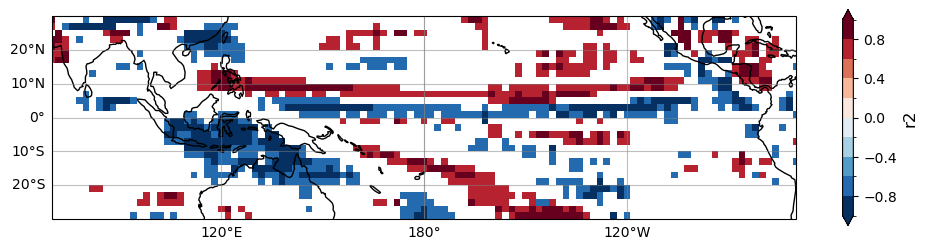

In [56]:
fig, axs = plt.subplots(1,1, subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}, figsize=(12,4))
from matplotlib import colors as mcolors
clevels_pi = np.arange(-1,1.2,0.2)  # for sst
divnorm = mcolors.BoundaryNorm(clevels_pi, plt.colormaps['RdBu_r'].N, clip=True)

exp_indices = [0,1,2,3,6,4,5]
corr_coeff = np.zeros([90,180])
for i in range(map_70.shape[1]):
    for j in range(map_70.shape[2]):
        a, b, r_value, p_value, std_err =  stats.linregress(lambdas_agg[3][exp_indices], map_70[exp_indices,i,j])
        corr_coeff[i,j] = r_value
        if r_value**2 < 0.4:
            corr_coeff[i,j] = np.nan

c = axs.pcolormesh(lons, lats, corr_coeff, cmap='RdBu_r', transform=ccrs.PlateCarree(), norm=divnorm)
gl = axs.gridlines(draw_labels={"bottom": "x", "left": "y"}, color='gray', alpha=0.5)
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size':10}    
#axs.set_title('Mean Omega')
axs.coastlines()
axs.set_extent([70, 290, -30, 30], crs=ccrs.PlateCarree())

cb2 = plt.colorbar(c, ax=axs, extend='both', shrink=0.7)
cb2.ax.set_ylabel('r2', fontsize=12)

plt.show()

find areas of ascent and descent

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


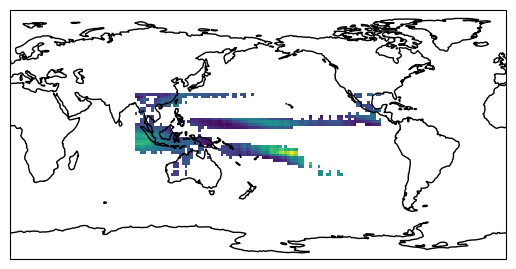

pct7
Already computed, reading clim..
pic7
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


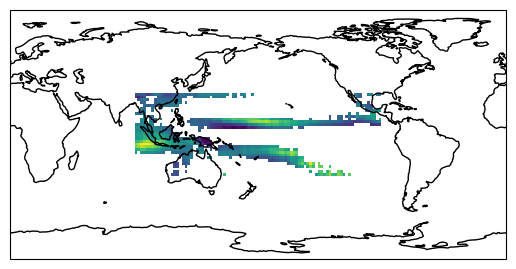

pct1
Already computed, reading clim..
pic1
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


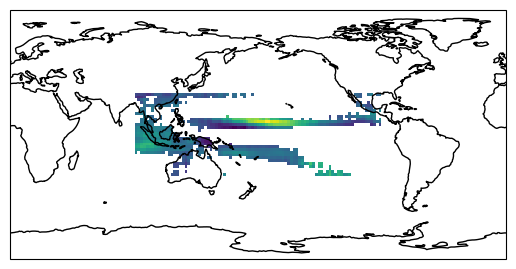

pct3
Already computed, reading clim..
pic3
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


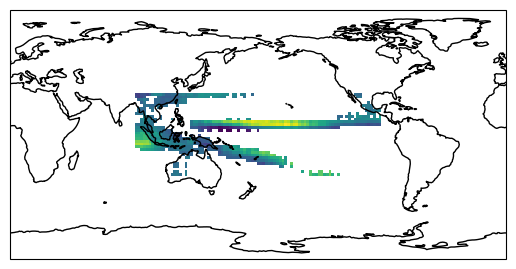

pct2
Already computed, reading clim..
pic2
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


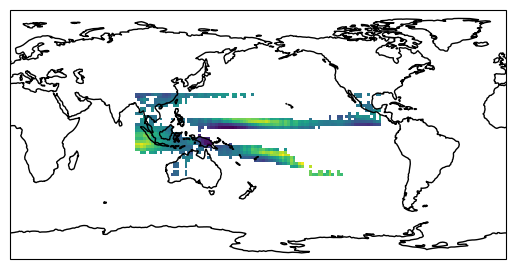

pct4
Already computed, reading clim..
pic4
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


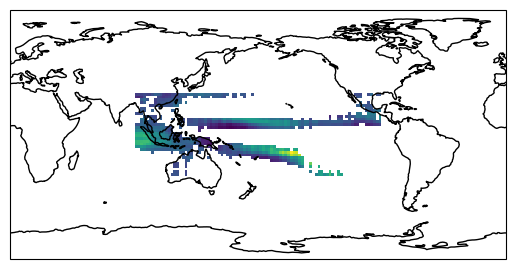

1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


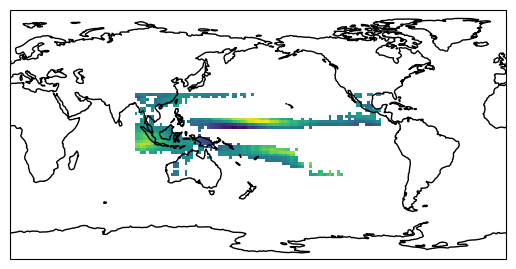

In [27]:
imp.reload(cr)

omega_up = []

for i, exp in enumerate(exps):
    omega_u = cr.return_var(exp, 'itcv', 'omega', 'atm3d', lat_bounds=[-30,30], lon_bounds=[90,270], cart_exp = cart_exp, cart_out=cart_out)
    
    omega_up.append(omega_u)

omega_up = np.array(omega_up)


In [ ]:
imp.reload(cr)

omega_up = []
omega_down = []

for i, exp in enumerate(exps):
    omega_u = cr.return_var(exp, 'itcv', 'omega', 'atm3d', lat_bounds=[-10,0], lon_bounds=[90,140], cart_exp = cart_exp, cart_out=cart_out)
    omega_d = cr.return_var(exp, 'itcv', 'omega', 'atm3d', lat_bounds=[10,20], lon_bounds=[190,240], cart_exp = cart_exp, cart_out=cart_out)
    
    omega_up.append(omega_u)
    omega_down.append(omega_d)

omega_up = np.array(omega_up)
omega_down = np.array(omega_down)

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


pct7
Already computed, reading clim..
pic7
Already computed, reading clim..


...

/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1009: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))


In [28]:
omega_up

array([0.00056381, 0.00058557, 0.00062881, 0.00049095, 0.00056745,
       0.00042655, 0.00054223])

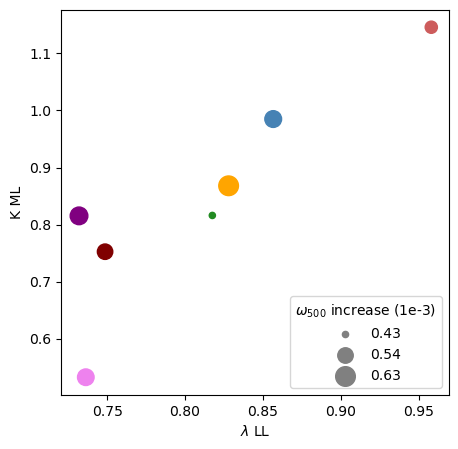

In [30]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
s_vals = omega_up
s_scaled = 20 + (s_vals - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

scatter = ax.scatter(lambdas_agg[3], kappas_agg[2], color=colors, s=s_scaled) #, sizes=(20,50))
ax.set_xlabel(r'$\lambda$ LL')
ax.set_ylabel('K ML')

ref_values = [s_vals.min(), s_vals.mean(), s_vals.max()]  # or pick specific values
ref_sizes  = 20 + (np.array(ref_values) - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

legend_handles = [
    ax.scatter([], [], s=size, color='gray', label=f'{val*1e3:.2f}')
    for val, size in zip(ref_values, ref_sizes)
]

ax.legend(handles=legend_handles, title=r'$\omega_{500}$ increase (1e-3)', loc='lower right')
plt.show()

In [ ]:
imp.reload(cr)
maxHC = np.zeros(len(exps))
latHC = np.zeros(len(exps))

maxHC_c = np.zeros(len(exps))
latHC_c = np.zeros(len(exps))

minHC = np.zeros(len(exps))
lat_minHC = np.zeros(len(exps)) 
minHC_c = np.zeros(len(exps))
lat_minHC_c = np.zeros(len(exps))

for i, exp in enumerate(exps):
    maxHC[i], latHC[i], maxHC_c[i], latHC_c[i], minHC[i], lat_minHC[i], minHC_c[i], lat_minHC_c[i] = cr.return_max_500hpa(exp, 'itcv', 'psi', 'atm3d',cart_exp = cart_exp, cart_out=cart_out)


pct6
Already computed, reading clim..
pic6
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1008: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))
/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


pct7
Already computed, reading clim..
pic7
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1008: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))
/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


pct1
Already computed, reading clim..
pic1
Already computed, reading clim..


...

/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1008: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))
/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


pct4
Already computed, reading clim..
pic4
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1008: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))
/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


1pc0
Already computed, reading clim..
ctl0
Already computed, reading clim..


/lus/h2resw01/hpcperm/itcv/analysis/Codes/ece-diags/check_multiexp/check_run.py:1008: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  x_ds = xr.concat(okdict.values(), dim=pd.Index(okdict.keys(), name='exp'))
/perm/itcv/Miniforge3/envs/clima/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


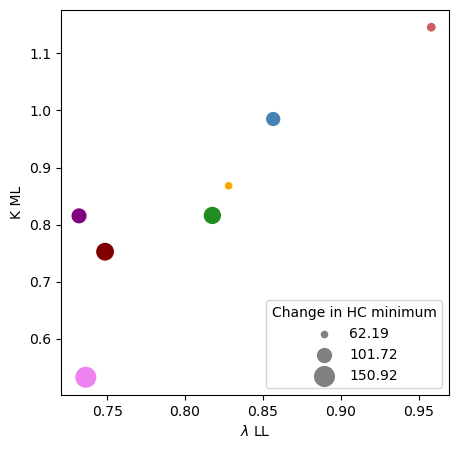

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
s_vals = (minHC - minHC_c) 
s_scaled = 20 + (s_vals - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

scatter = ax.scatter(lambdas_agg[3], kappas_agg[2], color=colors, s=s_scaled) #, sizes=(20,50))
ax.set_xlabel(r'$\lambda$ LL')
ax.set_ylabel('K ML')

ref_values = [s_vals.min(), s_vals.mean(), s_vals.max()]  # or pick specific values
ref_sizes  = 20 + (np.array(ref_values) - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

legend_handles = [
    ax.scatter([], [], s=size, color='gray', label=f'{val*1e-8:.2f}')
    for val, size in zip(ref_values, ref_sizes)
]

ax.legend(handles=legend_handles, title='Change in HC minimum', loc='lower right')
plt.show()

Text(0, 0.5, 'maxHC')

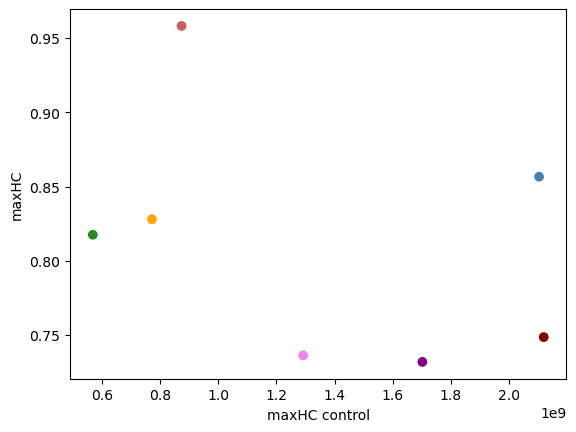

In [ ]:
#plt.scatter(maxHC_c,maxHC, color=colors)
plt.scatter(maxHC-maxHC_c, lambdas_agg[3], color=colors)
#plt.plot(maxHC, maxHC, color='k')
plt.xlabel('maxHC control')
plt.ylabel('maxHC')
#plt.scatter(lambdas_agg[3], kappas_agg[2], s=maxHC/1e8, color=colors)
#plt.scatter(maxHC, kappas_agg[2],  color=colors)
#plt.scatter(maxHC, lambdas_agg[3],  color=colors, marker='x')

Tests with surface fluxes

In [ ]:
imp.reload(cr)

shf_30 = []
shf_10 = []
shf_3 = []

for i, exp in enumerate(exps):
    shf_exp = cr.return_var(exp, 'itcv', 'qt_oce', 'oce', lat_bounds=[-30, 30], lon_bounds=[105,-90], cart_exp = cart_exp, cart_out=cart_out)
    shf_10_exp = cr.return_var(exp, 'itcv', 'qt_oce', 'oce', lat_bounds=[-10, 10], lon_bounds=[105,-90], cart_exp = cart_exp, cart_out=cart_out)
    shf_3_exp = cr.return_var(exp, 'itcv', 'qt_oce', 'oce', lat_bounds=[-3, 3], lon_bounds=[105,-90], cart_exp = cart_exp, cart_out=cart_out)

    shf_30.append(shf_exp)
    shf_10.append(shf_10_exp)
    shf_3.append(shf_3_exp)

shf_30 = np.array(shf_30)
shf_10 = np.array(shf_10)
shf_3 = np.array(shf_3)

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct2
Already computed, reading clim..
pic2
Already computed, reading clim..
pct2
Already

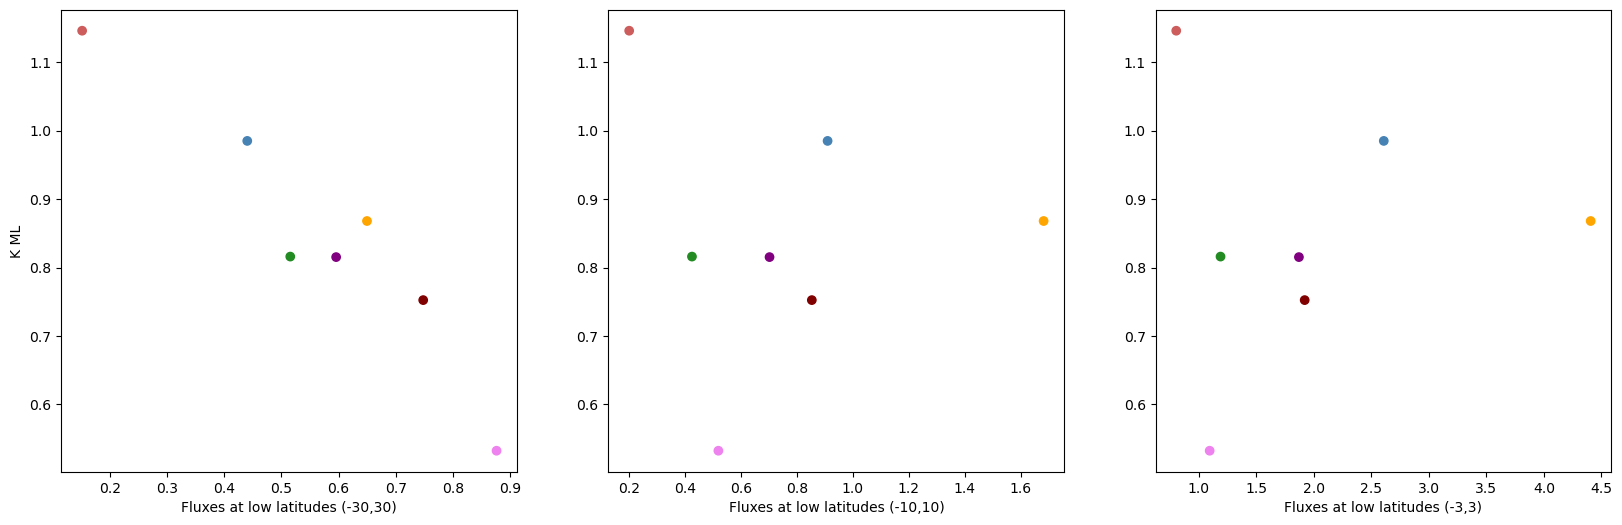

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(20,6))
ax[0].scatter(shf_30,kappas_agg[2], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_30, kappas_agg[2])
#ax[0].text(0.5,0.5,f'R = {r_value:.2f}')
ax[0].set_xlabel('Fluxes at low latitudes (-30,30)')
ax[0].set_ylabel('K ML')

ax[1].scatter(shf_10, kappas_agg[2], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_10, kappas_agg[2])
#ax[1].text(0.7,0.5,f'R = {r_value:.2f}')
ax[1].set_xlabel('Fluxes at low latitudes (-10,10)')

ax[2].scatter(shf_3, kappas_agg[2], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_3,kappas_agg[2])
#ax[2].text(2,0.5,f'R = {r_value:.2f}')
ax[2].set_xlabel('Fluxes at low latitudes (-3,3)')
plt.show()

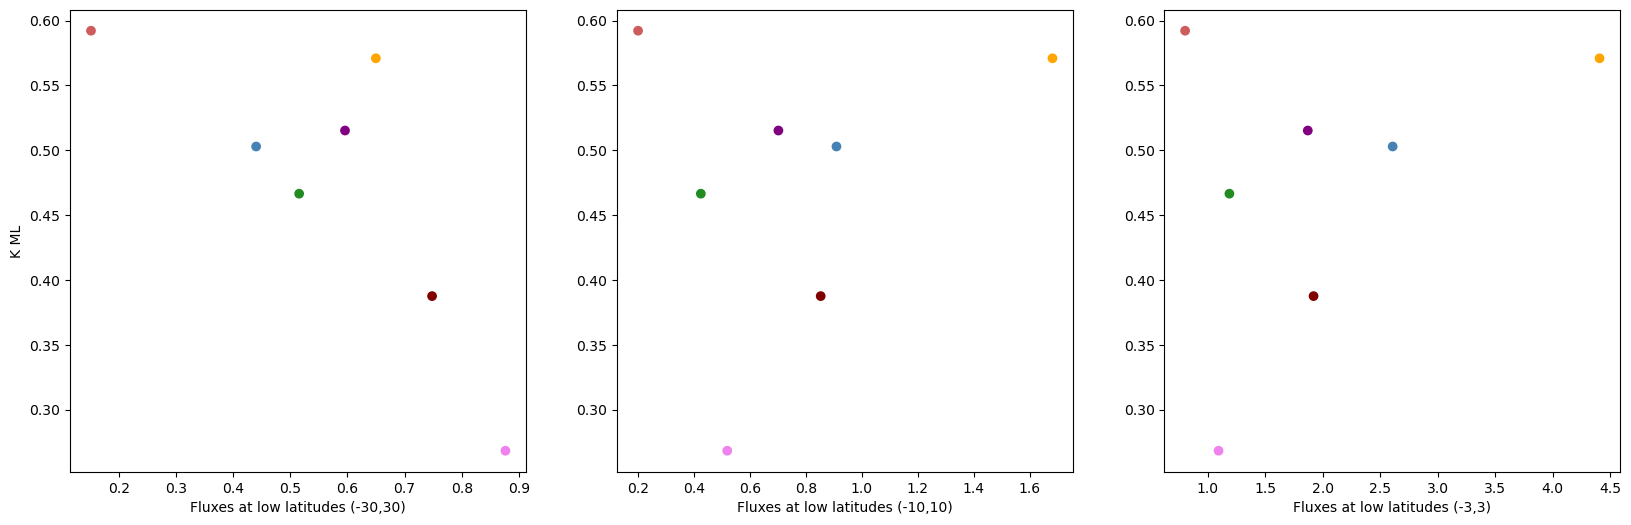

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(20,6))
ax[0].scatter(shf_30,kappas[4], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_30, kappas[4])
#ax[0].text(0.5,0.5,f'R = {r_value:.2f}')
ax[0].set_xlabel('Fluxes at low latitudes (-30,30)')
ax[0].set_ylabel('K ML')

ax[1].scatter(shf_10, kappas[4], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_10, kappas[4])
#ax[1].text(0.7,0.5,f'R = {r_value:.2f}')
ax[1].set_xlabel('Fluxes at low latitudes (-10,10)')

ax[2].scatter(shf_3, kappas[4], color=colors)
a,b,r_value, p_value, std_err =  stats.linregress(shf_3,kappas[4])
#ax[2].text(2,0.5,f'R = {r_value:.2f}')
ax[2].set_xlabel('Fluxes at low latitudes (-3,3)')
plt.show()

# 3. K ll vs L ll: SST gradient/ENSO effects/tropical pacific convection shift

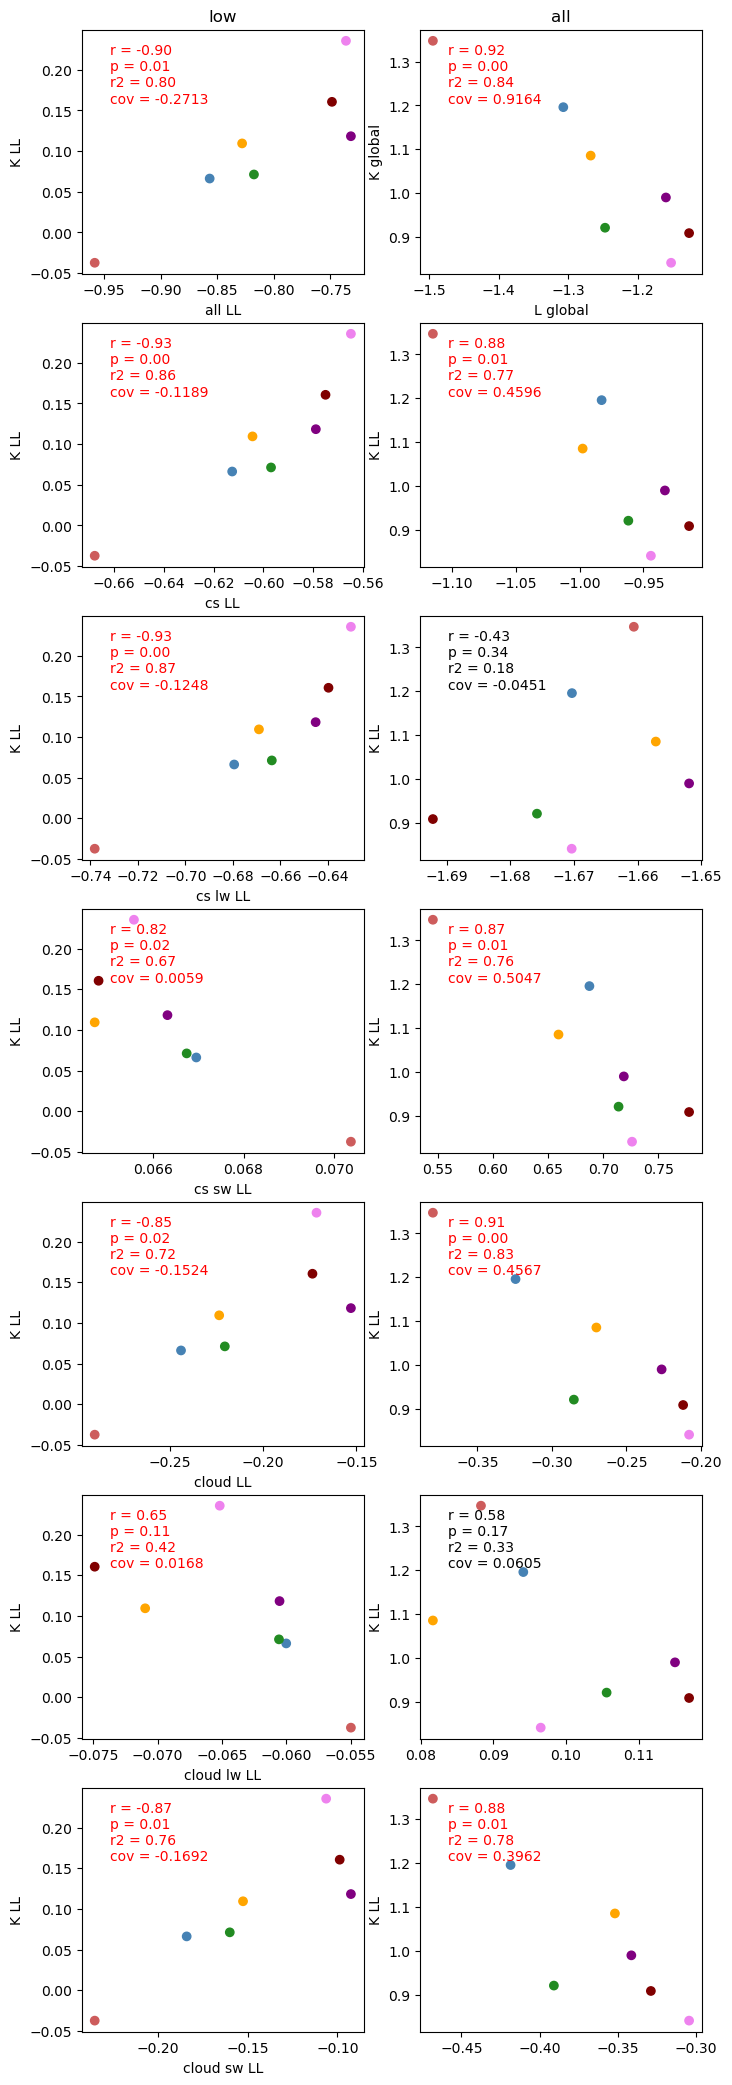

In [ ]:
fig, ax = plt.subplots(7,2, figsize=(8,26))
labels = ['all', 'high', 'mid','low']
forcings = ['all', 'cs', 'cs lw', 'cs sw', 'cloud','cloud lw', 'cloud sw']
colors=np.array(['violet', 'purple', 'orange', 'indianred','steelblue','forestgreen', 'maroon'])

indexes = [3,0]
exps_indexes = [0,1,2,3,4,5,6]
# lambdas_c has shape (forcing,region,n_exps) and kappas has shape (regions,n_exps)

sigma_Kg = np.std(kappas_agg[0,:], ddof=1)
sigma_Lg = np.std(lambdas_agg[0,:], ddof=1)
denom_global = sigma_Kg * sigma_Lg

for i in range(7):
    for j, index in enumerate(indexes):
        a, b, r_value, p_value, std_err =  stats.linregress(lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes])
        ax[i,j].scatter(-lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes], color=colors[exps_indexes])
        cov = np.cov(lambdas_c_agg[i,index][exps_indexes], kappas_agg[index,exps_indexes])[0,1]/denom_global
        #ax[i,j].plot(lambdas_c[i,index], [a*(x) + b for x in lambdas_c[i,index]], color='black', linestyle='--', label=f'Fit {labels[index]}')
        if r_value**2 > 0.4:
            color_text = 'red'
        else:         
            color_text = 'black'
        ax[i,j].text(0.1, 0.7, f'r = {r_value:.2f}\np = {p_value:.2f}\nr2 = {r_value**2:.2f}\ncov = {cov:.4f}', transform=ax[i,j].transAxes, color=color_text)

        if i == 0:
            ax[i,j].set_title(labels[index])
    
        ax[i,0].set_xlabel(forcings[i]+ ' LL')
        ax[i,j].set_ylabel('K LL')
    
ax[0,1].set_ylabel('K global')
ax[0,1].set_xlabel('L global')
plt.show()

https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni

Remember that atmosphere and ocean have different grid!! \
crossing dateline for ocean (-180,180), not for atmosphere (0,360)

In [ ]:
imp.reload(cr)

tos_tropics = [] # temperature of whole LL Pacific
tos34 = []  # temperature in the central Pacific (extended nino 3.4 region)
tos_ll = []
tos_subtropics = []
tos_subtropics_n = []

tos_west10 = []  # compute gradient explicitly 
tos_east10 = []

for i, exp in enumerate(exps):
    #tos_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-30, 30], lon_bounds= [-180,180],cart_exp = cart_exp, cart_out=cart_out)
    tos_subtropics_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-30, -10], lon_bounds= [-130,-90],cart_exp = cart_exp, cart_out=cart_out)
    tos_sub_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[10,30], lon_bounds= [180,-120],cart_exp = cart_exp, cart_out=cart_out)
    
    #tos_ll.append(tos_exp)
    tos_subtropics.append(tos_subtropics_exp)
    tos_subtropics_n.append(tos_sub_exp)
    
    # tos_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-30, 30], lon_bounds= [120,-90],cart_exp = cart_exp, cart_out=cart_out)
    # tos34_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-10,10], lon_bounds= [170,-120],cart_exp = cart_exp, cart_out=cart_out)
    
    # tos_tropics.append(tos_exp)
    # tos34.append(tos34_exp)
    
    tos_west_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-20,20], lon_bounds= [140,-160],cart_exp = cart_exp, cart_out=cart_out)
    #tos_east_exp = cr.return_var(exp, 'itcv', 'tos', 'oce', lat_bounds=[-5,5], lon_bounds= [-130,-90],cart_exp = cart_exp, cart_out=cart_out)

    tos_west10.append(tos_west_exp)
    #tos_east10.append(tos_east_exp)
    
#tos_ll = np.array(tos_ll)
tos_subtropics = np.array(tos_subtropics)
tos_subtropics_n = np.array(tos_subtropics_n)
#tos_tropics = np.array(tos_tropics)
#tos34 = np.array(tos34)
tos_west10 = np.array(tos_west10)
#tos_east10 = np.array(tos_east10)

Testing Andrews and Webb 2018 framework for SST controls on clouds and lapse rate \
Could redefine regions depending on ECE4 exact pattern of warming and clouds.

In [ ]:
tas_year70 = [2.3460411198163076, 2.2170519074516752, 2.0646596355268514, 1.6655365417645518, 1.963871167161966, 2.1608291586707233, 2.3434379318936864]

In [ ]:
imp.reload(cr)

tos_wp = [] 
tos_se = []
tos_ne = []

for i, exp in enumerate(exps):
    tos_wp_exp = cr.return_var(exp, 'itcv', 'tas', 'atm', lat_bounds=[-15,15], lon_bounds= [150,170],cart_exp = cart_exp, cart_out=cart_out)
    tos_se_exp = cr.return_var(exp, 'itcv', 'tas', 'atm', lat_bounds=[-30,0], lon_bounds= [260,280],cart_exp = cart_exp, cart_out=cart_out)
    tos_ne_exp = cr.return_var(exp, 'itcv', 'tas', 'atm', lat_bounds=[0,30], lon_bounds= [210,240],cart_exp = cart_exp, cart_out=cart_out)

    tos_wp.append(tos_wp_exp)
    tos_se.append(tos_se_exp)
    tos_ne.append(tos_ne_exp)

tos_wp = np.array(tos_wp)
tos_se = np.array(tos_se)
tos_ne = np.array(tos_ne)

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct2
Already computed, reading clim..
pic2
Already computed, reading clim..
pct2
Already

In [ ]:
index = (tos_ne - tos_wp)/tas_year70

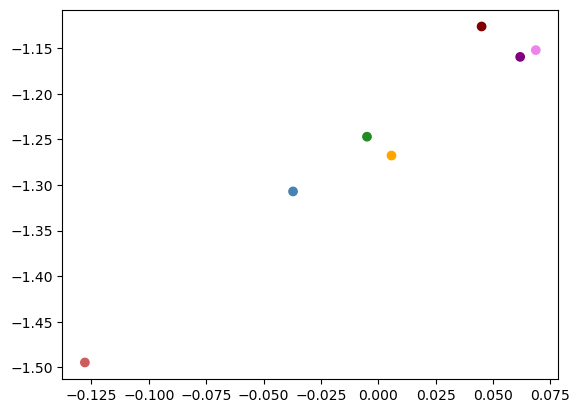

In [ ]:
plt.scatter(index, -lambdas_c_agg[0,0], color=colors)
plt.show()

Other analysis with clouds

In [ ]:
imp.reload(cr)

clouds_tropics = []
clouds_mid = []
clouds_low = []
clouds_high = []
cloud_subtropics_s = []
cloud_subtropics_n = []

for i, exp in enumerate(exps):
    # clouds_exp = cr.return_var(exp, 'itcv', 'cll', 'atm', lat_bounds=[-30, 30], lon_bounds= [105,270],cart_exp = cart_exp, cart_out=cart_out)
    # clouds_exp_m = cr.return_var(exp, 'itcv', 'clm', 'atm', lat_bounds=[-30, 30], lon_bounds= [105,270],cart_exp = cart_exp, cart_out=cart_out)
    # clouds_exp_h = cr.return_var(exp, 'itcv', 'clh', 'atm', lat_bounds=[-30, 30], lon_bounds= [105,270],cart_exp = cart_exp, cart_out=cart_out)    
    
    # clouds_mid.append(clouds_exp_m)
    # clouds_low.append(clouds_exp)
    # clouds_high.append(clouds_exp_h)
    # clouds_tropics.append(clouds_exp + clouds_exp_m + clouds_exp_h)

    cloud_subs_exp = cr.return_var(exp, 'itcv', 'cll', 'atm', lat_bounds=[-30,-10], lon_bounds= [230,270],cart_exp = cart_exp, cart_out=cart_out)
    cloud_subn_exp = cr.return_var(exp, 'itcv', 'cll', 'atm', lat_bounds=[10,30], lon_bounds= [180,240],cart_exp = cart_exp, cart_out=cart_out)

    cloud_subtropics_s.append(cloud_subs_exp)
    cloud_subtropics_n.append(cloud_subn_exp)
    
# clouds_tropics = np.array(clouds_tropics)
# clouds_mid = np.array(clouds_mid)
# clouds_low = np.array(clouds_low)   
# clouds_high = np.array(clouds_high)

cloud_subtropics_s = np.array(cloud_subtropics_s)
cloud_subtropics_n = np.array(cloud_subtropics_n)

pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct6
Already computed, reading clim..
pic6
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct7
Already computed, reading clim..
pic7
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct1
Already computed, reading clim..
pic1
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct3
Already computed, reading clim..
pic3
Already computed, reading clim..
pct2
Already computed, reading clim..
pic2
Already computed, reading clim..
pct2
Already

In [ ]:
import matplotlib.patches as patches

def draw_box(ax, lat_bounds, lon_bounds, label, color='red'):

    lat_min, lat_max = lat_bounds
    lon_min, lon_max = lon_bounds

    handles = []

    # Handle dateline crossing
    if lon_min < lon_max:
        boxes = [(lon_min, lon_max)]
    else:
        boxes = [(lon_min, 360), (0, lon_max)]

    for lon0, lon1 in boxes:
        rect = patches.Rectangle(
            (lon0, lat_min),
            lon1 - lon0,
            lat_max - lat_min,
            linewidth=2,
            edgecolor=color,
            facecolor='none',
            transform=ccrs.PlateCarree()
        )
        ax.add_patch(rect)
        handles.append(rect)

    # Return ONE handle for legend (not duplicates)
    legend_patch = patches.Patch(edgecolor=color, facecolor='none', label=label, linewidth=2)

    return legend_patch

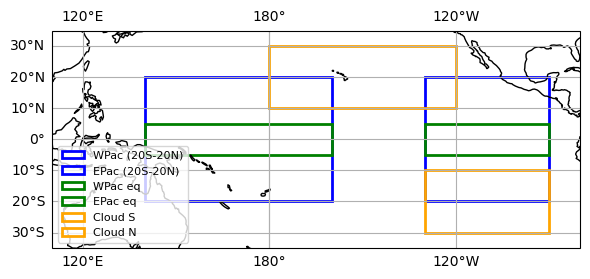

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,5),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

ax.coastlines()
ax.set_extent([110, 280, -35, 35], crs=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
legend_handles = []

# --- Add regions ---
legend_handles.append(draw_box(ax, [-20,20], [140,200], 'WPac (20S-20N)', 'blue'))
legend_handles.append(draw_box(ax, [-20,20], [-130,-90], 'EPac (20S-20N)', 'blue'))

legend_handles.append(draw_box(ax, [-5,5], [140,200], 'WPac eq', 'green'))
legend_handles.append(draw_box(ax, [-5,5], [-130,-90], 'EPac eq', 'green'))

# legend_handles.append(draw_box(ax, [-30,-10], [230,270], 'SST S subtropics', 'purple'))
# legend_handles.append(draw_box(ax, [10,30], [180,270], 'SST N subtropics', 'purple'))

legend_handles.append(draw_box(ax, [-30,-10], [230,270], 'Cloud S', 'orange'))
legend_handles.append(draw_box(ax, [10,30], [180,240], 'Cloud N', 'orange'))

# --- Legend ---
ax.legend(handles=legend_handles,
          loc='lower left',
          fontsize=8,
          frameon=True)

plt.tight_layout()
plt.show()

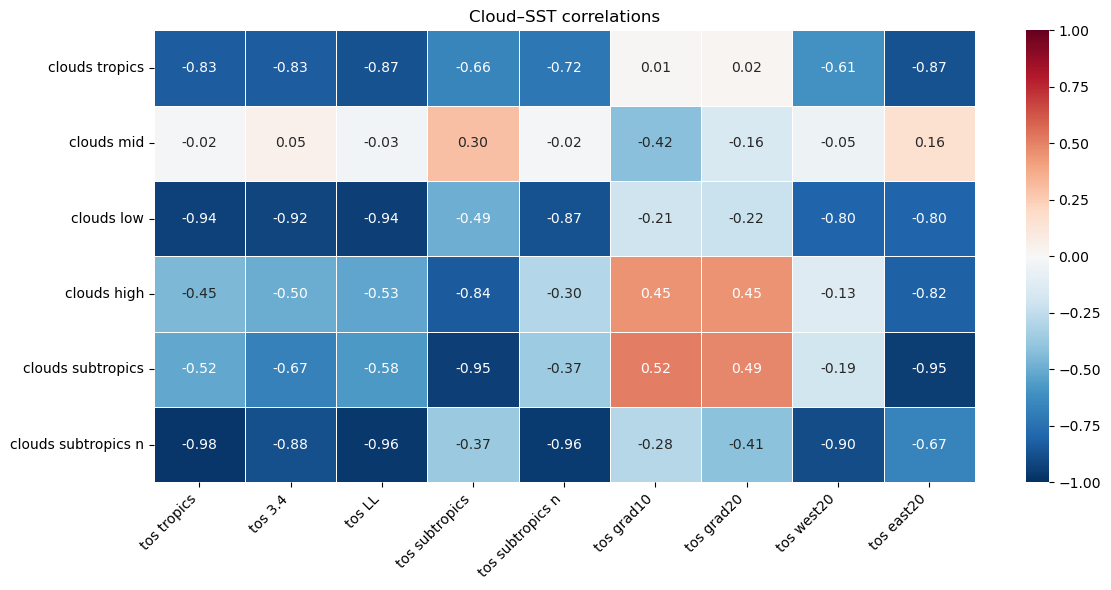

In [ ]:
import seaborn as sns
clouds_changes = [clouds_tropics, clouds_mid, clouds_low, clouds_high, cloud_subtropics_s, cloud_subtropics_n]
sst_changes = [tos_tropics, tos34, tos_ll, tos_subtropics, tos_subtropics_n, tos_west10-tos_east10, tos_west20-tos_east20, tos_west20, tos_east20]

# labels = ['clouds tropics', 'clouds mid', 'clouds low', 'clouds high', 'clouds subtropics', 'clouds subtropics n', 'tos tropics', 'tos 3.4', 'tos LL', 'tos subtropics', 'tos subtropics n', 'tos gradient 10', 'tos gradient 20','tos west20','tos east20']
# df = np.array(clouds_changes + sst_changes)
# corr = np.corrcoef(df)
# mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
# fig, ax = plt.subplots(figsize=(10, 8))
# sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
#             vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels,
#             linewidths=0.5, ax=ax)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()

clouds = np.array(clouds_changes)   # shape (Nc, Nexp)
sst    = np.array(sst_changes)      # shape (Ns, Nexp)

Nc = clouds.shape[0]
Ns = sst.shape[0]

corr_cs = np.zeros((Nc, Ns))

for i in range(Nc):
    for j in range(Ns):
        corr_cs[i, j] = np.corrcoef(clouds[i], sst[j])[0, 1]

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(corr_cs,
            annot=True, fmt='.2f',
            cmap='RdBu_r',
            vmin=-1, vmax=1,
            xticklabels=[
                'tos tropics', 'tos 3.4', 'tos LL', 'tos subtropics',
                'tos subtropics n', 'tos grad10', 'tos grad20',
                'tos west20','tos east20'
            ],
            yticklabels=[
                'clouds tropics', 'clouds mid', 'clouds low',
                'clouds high', 'clouds subtropics', 'clouds subtropics n'
            ],
            linewidths=0.5,
            ax=ax)

ax.set_title('Cloud–SST correlations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

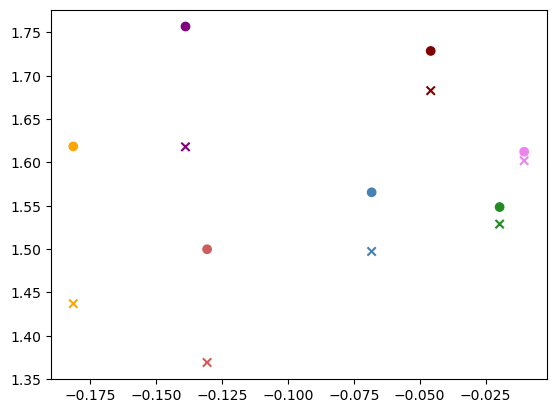

In [ ]:
plt.scatter(tos_west10-tos_east10, tos_east10, color=colors)
plt.scatter(tos_west10-tos_east10, tos_west10, color=colors, marker='x')

In [ ]:
clouds = clouds_low + clouds_mid + clouds_high

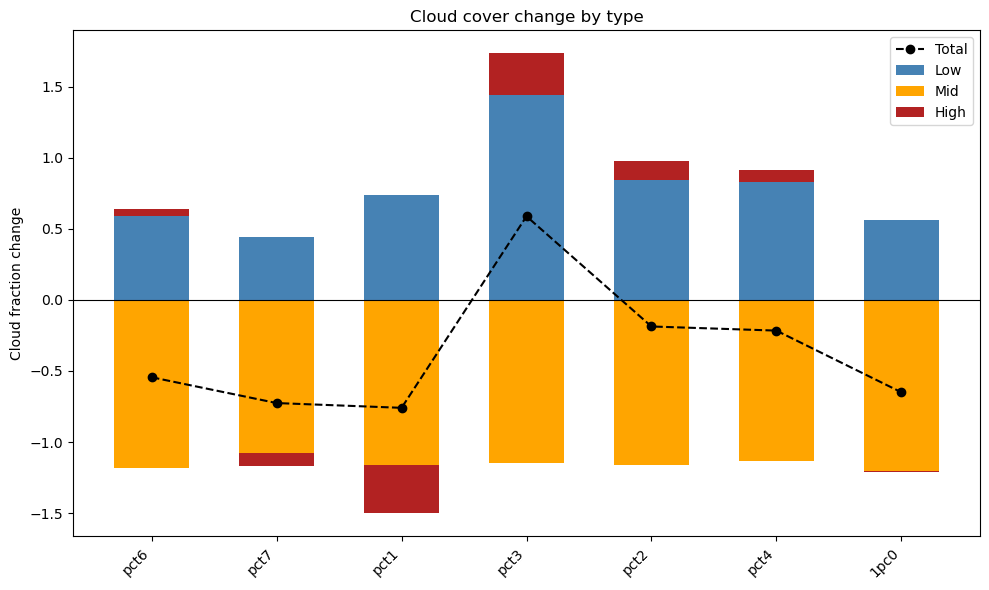

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

exp_labels = [exp[0] for exp in exps]
x = np.arange(len(exps))
width = 0.6

low_change  = clouds_low  #- clouds_low[0]
mid_change  = clouds_mid  #- clouds_mid[0]
high_change = clouds_high #- clouds_high[0]

pos_bottom = np.zeros(len(exps))
neg_bottom = np.zeros(len(exps))

for change, color, label in zip([low_change, mid_change, high_change],
                                  ['steelblue', 'orange', 'firebrick'],
                                  ['Low', 'Mid', 'High']):
    pos = np.where(change > 0, change, 0)
    neg = np.where(change < 0, change, 0)
    ax.bar(x, pos, width, bottom=pos_bottom, color=color, label=label)
    ax.bar(x, neg, width, bottom=neg_bottom, color=color)  # no label to avoid duplicate
    pos_bottom += pos
    neg_bottom += neg

# total as line
total_change = low_change + mid_change + high_change
ax.plot(x, total_change, 'ko--', label='Total', zorder=5)

ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(exp_labels, rotation=45, ha='right')
ax.set_ylabel('Cloud fraction change')
ax.set_title('Cloud cover change by type')
ax.legend()
plt.tight_layout()
plt.show()

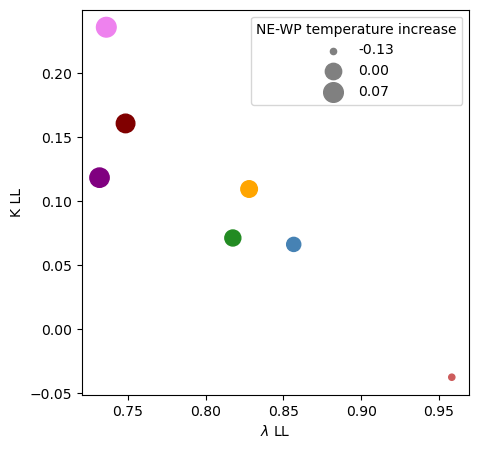

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
#scatter = ax.scatter(lambdas_agg[3],kappas_agg[3], c=(tos_subtropics_n))
#scatter = ax.scatter(lambdas_agg[3], kappas_agg[3], color=colors, s=clouds_low*50)

s_vals = (index)
s_scaled = 20 + (s_vals - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

scatter = ax.scatter(lambdas_agg[3], kappas_agg[3], color=colors, s=s_scaled) #, sizes=(20,50))
ax.set_xlabel(r'$\lambda$ LL')
ax.set_ylabel('K LL')

ref_values = [s_vals.min(), s_vals.mean(), s_vals.max()]  # or pick specific values
ref_sizes  = 20 + (np.array(ref_values) - s_vals.min()) / (s_vals.max() - s_vals.min()) * 180

legend_handles = [
    ax.scatter([], [], s=size, color='gray', label=f'{val:.2f}')
    for val, size in zip(ref_values, ref_sizes)
]

ax.legend(handles=legend_handles, title='NE-WP temperature increase', loc='upper right')
plt.show()